Ncov Crawling

In [3]:
# Importing libraries
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
import pandas as pd
from selenium.webdriver.common.keys import Keys
from time import sleep
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction import _stop_words

In [17]:
#Before loop
New_deaths_of_80s = []
New_deaths_of_70s = []
New_deaths_of_60s = []
New_deaths_of_50s = []
New_deaths_of_40s = []
New_deaths_of_30s = []
New_deaths_of_20s = []
New_deaths_of_10s = []
New_deaths_of_00s = []
Total_years_lost = []
Lostwealth = []

#To make sure it's clear
thisweek_dead00s_total = 0
thisweek_dead10s_total = 0
thisweek_dead20s_total = 0
thisweek_dead30s_total = 0
thisweek_dead40s_total = 0
thisweek_dead50s_total = 0
thisweek_dead60s_total = 0
thisweek_dead70s_total = 0
thisweek_dead80s_total = 0

# Define variables
GDP_per_capita = 31489.12
remaining_lifeexpectancy_85 = 6.9
remaining_lifeexpectancy_75 = 13.3
remaining_lifeexpectancy_65 = 21.5
remaining_lifeexpectancy_55 = 30.4
remaining_lifeexpectancy_45 = 39.6
remaining_lifeexpectancy_35 = 49.2
remaining_lifeexpectancy_25 = 59.0
remaining_lifeexpectancy_15 = 68.8
remaining_lifeexpectancy_05 = 78.7

webdriver_options = webdriver.ChromeOptions()
webdriver_options.add_argument('headless') ##창 띄우지 만 상태에서 알아서 해라
webdriver_options.add_argument('window-size=1920x1080') ## 창 사이즈 지정해줘야 렉 안 먹음
webdriver_options.add_argument("disable-gpu") ##크롬드라이버가 gpu 부스터를 쓰기 때문에 가끔렉 먹는거 방지용
webdriver_options.add_argument("lang=ko-KR") ##위에 코드 3개가 쓰면 영어로 전체를 돌려버려서 언어 한국말로 바꿔주기


# Generate urls
time = pd.date_range(start="2021-12-25", periods=23, freq= "w-Sat")
driver = webdriver.Chrome(service=Service("/Users/aiym/chromedriver"))


for t in time:
    x = t.strftime("%Y%m%d")
    url = "http://web.archive.org/web/" + x + "/http:/ncov.mohw.go.kr/bdBoardList_Real.do?brdId=1&brdGubun=11&ncvContSeq=&contSeq=&board_id=&gubun="
    
    driver.get(url)
    sleep(5)
    
    thisweek_doc = BeautifulSoup(driver.page_source, "html.parser")
    element_table = thisweek_doc.find_all(name='table')
    tables = pd.read_html(str(element_table))
    table = tables[-1]
    
    death = table['사망자(%)']
    death = list(death)
    n_death = []
    for n in death:
        s_death = n.split('\xa0')
        n_death.append(s_death[0])
        
    num_death = []
    for t in n_death:
        a = int(t.replace(",",""))
        num_death.append(a)

    thisweek_dead80s_total = num_death[0]
    thisweek_dead70s_total = num_death[1]
    thisweek_dead60s_total = num_death[2]
    thisweek_dead50s_total = num_death[3]
    thisweek_dead40s_total = num_death[4]
    thisweek_dead30s_total = num_death[5]
    thisweek_dead20s_total = num_death[6]
    thisweek_dead10s_total = num_death[7]
    thisweek_dead00s_total = num_death[8]
    
    try:
        thisweek_newlydead80s = thisweek_dead80s_total - lastweek_dead80s_total
        thisweek_newlydead70s = thisweek_dead70s_total - lastweek_dead70s_total
        thisweek_newlydead60s = thisweek_dead60s_total - lastweek_dead60s_total
        thisweek_newlydead50s = thisweek_dead50s_total - lastweek_dead50s_total
        thisweek_newlydead40s = thisweek_dead40s_total - lastweek_dead40s_total
        thisweek_newlydead30s = thisweek_dead30s_total - lastweek_dead30s_total
        thisweek_newlydead20s = thisweek_dead20s_total - lastweek_dead20s_total
        thisweek_newlydead10s = thisweek_dead10s_total - lastweek_dead10s_total
        thisweek_newlydead00s = thisweek_dead00s_total - lastweek_dead00s_total
        lostyears_85 = remaining_lifeexpectancy_85 * thisweek_newlydead80s
        lostyears_75 = remaining_lifeexpectancy_75 * thisweek_newlydead70s
        lostyears_65 = remaining_lifeexpectancy_65 * thisweek_newlydead60s
        lostyears_55 = remaining_lifeexpectancy_55 * thisweek_newlydead50s
        lostyears_45 = remaining_lifeexpectancy_45 * thisweek_newlydead40s
        lostyears_35 = remaining_lifeexpectancy_35 * thisweek_newlydead30s
        lostyears_25 = remaining_lifeexpectancy_25 * thisweek_newlydead20s
        lostyears_15 = remaining_lifeexpectancy_15 * thisweek_newlydead10s
        lostyears_05 = remaining_lifeexpectancy_05 * thisweek_newlydead00s
        totalcost_KRGOV = GDP_per_capita * (lostyears_85 + lostyears_75 + lostyears_65 + lostyears_55 + lostyears_45 + lostyears_35 + lostyears_25 + lostyears_15 + lostyears_05)

        New_deaths_of_80s.extend([thisweek_newlydead80s])
        New_deaths_of_70s.extend([thisweek_newlydead70s])
        New_deaths_of_60s.extend([thisweek_newlydead60s])
        New_deaths_of_50s.extend([thisweek_newlydead50s])
        New_deaths_of_40s.extend([thisweek_newlydead40s])
        New_deaths_of_30s.extend([thisweek_newlydead30s])
        New_deaths_of_20s.extend([thisweek_newlydead20s])
        New_deaths_of_10s.extend([thisweek_newlydead10s])
        New_deaths_of_00s.extend([thisweek_newlydead00s])
        Total_years_lost.extend([lostyears_85 + lostyears_75 + lostyears_65 + lostyears_55 + lostyears_45 + lostyears_35 + lostyears_25 + lostyears_15 + lostyears_05])
        Lostwealth.extend([totalcost_KRGOV])
    
    #for first week
    except:
        dummy = 0
        
    lastweek_dead80s_total = thisweek_dead80s_total
    lastweek_dead70s_total = thisweek_dead70s_total
    lastweek_dead60s_total = thisweek_dead60s_total
    lastweek_dead50s_total = thisweek_dead50s_total
    lastweek_dead40s_total = thisweek_dead40s_total
    lastweek_dead30s_total = thisweek_dead30s_total
    lastweek_dead20s_total = thisweek_dead20s_total
    lastweek_dead10s_total = thisweek_dead10s_total
    lastweek_dead00s_total = thisweek_dead00s_total

driver.quit()   

In [18]:
THEFRAME = pd.DataFrame({"Week ending in": time, "80s deaths": New_deaths_of_80s, "70s deaths": New_deaths_of_70s, "60s deaths": New_deaths_of_60s, 
              "50s deaths": New_deaths_of_50s, "40s deaths": New_deaths_of_40s, "30s deaths": New_deaths_of_30s,
              "20s deaths": New_deaths_of_20s, "10s deaths": New_deaths_of_10s, "00s deaths": New_deaths_of_00s,
              "Total years lost": Total_years_lost, "Lost GDP": Lostwealth})

display(THEFRAME)

,Week ending in,80s deaths,70s deaths,60s deaths,50s deaths,40s deaths,30s deaths,20s deaths,10s deaths,00s deaths,Total years lost,Lost GDP
0,2021-12-25,-11557,-4166,-2059,-733,-250,-74,-47,-9,-18,-220052.4,-6.929256e+09
1,2022-01-01,-11359,-4028,-1972,-714,-245,-73,-46,-9,-18,-214096.5,-6.741710e+09
2,2022-01-08,-11224,-3908,-1909,-702,-237,-68,-46,-9,-18,-209286.9,-6.590260e+09
3,2022-01-15,-11124,-3835,-1857,-688,-234,-67,-45,-9,-18,-205855.4,-6.482205e+09
4,2022-01-22,-10990,-3760,-1821,-678,-230,-67,-45,-9,-18,-202696.9,-6.382747e+09
5,2022-01-29,-10885,-3712,-1793,-674,-226,-64,-45,-9,-18,-200304.4,-6.307409e+09
6,2022-02-05,-10801,-3687,-1773,-666,-224,-63,-45,-8,-18,-198521.9,-6.251280e+09
7,2022-02-12,-10693,-3656,-1753,-657,-221,-62,-45,-8,-18,-196492.8,-6.187385e+09
8,2022-02-19,-10462,-3578,-1722,-643,-217,-60,-45,-8,-18,-192512.6,-6.062052e+09
9,2022-02-26,-10118,-3460,-1674,-626,-212,-58,-42,-8,-16,-186390.0,-5.869257e+09


In [19]:
sum=0
for i in range(0, len(Lostwealth)):
    sum=sum+Lostwealth[i]
print(sum)

-89416722426.92802


In [9]:
total_l = []
sum_old = []
i = 0
length = len(THEFRAME['Week ending in'])
while (i<length):
    j = 1
    total = 0
    while (j<=9):
        total = total + int(THEFRAME.iloc[i,j])
        j = j + 1
    total_l.append(total)
    sum_o = THEFRAME.iloc[i,1] + THEFRAME.iloc[i,2] + THEFRAME.iloc[i,3]
    sum_old.append(sum_o)
    i = i + 1

print(total_l)
print(sum_old)

[-1295, 449, 343, 244, 259, 192, 141, 172, 360, 539, 852, 1599, 2033, 2471, 2336, 2186, 1671, 1041, 742, 485, 301, 304, 193]
[-1211, 423, 318, 225, 245, 181, 129, 159, 340, 510, 800, 1502, 1925, 2346, 2188, 2067, 1587, 971, 696, 443, 276, 279, 172]


In [10]:
p_old = []
i = 0
l = len(total_l)

while (i < l):
    percentage = (sum_old[i] / total_l[i]) 
    p_old.append(percentage)
    i = i + 1

print(p_old)

[0.9351351351351351, 0.9420935412026726, 0.9271137026239067, 0.9221311475409836, 0.9459459459459459, 0.9427083333333334, 0.9148936170212766, 0.9244186046511628, 0.9444444444444444, 0.9461966604823747, 0.9389671361502347, 0.9393370856785491, 0.9468765371372356, 0.9494131930392553, 0.9366438356164384, 0.9455626715462031, 0.9497307001795332, 0.9327569644572526, 0.9380053908355795, 0.9134020618556701, 0.9169435215946844, 0.9177631578947368, 0.8911917098445595]


In [22]:
sum=0
for i in range(0, len(p_old)):
    sum=sum+p_old[i]
average=sum/len(p_old)
print(average)

0.933116308617877


We found problem that the ratio of death of age 60s to 80s are too high

Webmd Crawling and NLP

In [23]:
urls = []
for i in range (1, 5):
    url = "https://www.webmd.com/drugs/drugreview-180368-pfizer-biontech-covid-19-vaccine-pf-eua-intramuscular?conditionid=&sortval=1&pagenumber=" + str(i)
    urls.append(url)

In [30]:
import random
effectiveness_ratings_array = []
ease_of_use_ratings_array = []
satisfaction_ratings_array = []
overall_ratings_array = []
text_array = []
age_array = []
gender_array = []
#Age_average_array is for our correlation analysis(making it numeric)
age_average_array = []



driver = webdriver.Chrome(service=Service("/Users/aiym/chromedriver"))
driver.implicitly_wait(3)
driver.maximize_window()

for u in urls:
    driver.get(u)
    sleep(random.randrange(3,5))
    driver.switch_to.window(driver.window_handles[0])
    page = BeautifulSoup(driver.page_source, "html.parser")
    text = page.find_all(class_="description-text")
    reviews_holder = page.find_all(class_="categories")
    details = page.find_all(class_="details")
    for n in range(0, len(reviews_holder)):
        #This is the text
        text_array.append(text[n].text.strip().replace("Read More Read Less", "").replace("\n",""))
    
        #This is the ratings
        effectiveness_star_count= float(reviews_holder[n].section.div.attrs["aria-valuenow"])
        ease_of_use_star_count= float(reviews_holder[n].section.next_sibling.div.attrs["aria-valuenow"])
        satisfaction_star_count= float(reviews_holder[n].section.next_sibling.next_sibling.div.attrs["aria-valuenow"])
        
        effectiveness_ratings_array.append(effectiveness_star_count)
        ease_of_use_ratings_array.append(ease_of_use_star_count)
        satisfaction_ratings_array.append(satisfaction_star_count)
        #Average of ratings are overall ratings
        overall_ratings_array.append((effectiveness_star_count+ease_of_use_star_count+satisfaction_star_count)/3)
    
    for n in range(0, len(reviews_holder)):
        # Let's retrieve the age data first
        worked_indicator = 0
        for count in range(0,len(details[n])):
            try:
                some_number = int(details[n].contents[count].text[1])

                #This code will not be run if 1st text is not convertible to int
                age_info = details[n].contents[1].text[1:-4]
                age_array.append(age_info)
                try:
                    age_average_info = (float(age_info[0:2])+float(age_info[-2:]))/2
                    age_average_array.append(age_average_info)
                except:
                    age_average_info = float(age_info[0:2])+5
                    age_average_array.append(age_average_info)
                worked_indicator = 1
            except:
                dummy = 0
        if worked_indicator == 0:
            # Which means, the "try" statement had not been run fully at any attempt
            age_array.append("NA")
            age_average_array.append("NA")
            

        # Now we retrieve gender data
        worked_indicator = 0
        for count in range(0,len(details[n])):        
            if details[n].contents[count].text[1:-4] == "Male":
                gender_array.append("Male")
                worked_indicator = 1
            elif details[n].contents[count].text[1:-4] == "Female":
                gender_array.append("Female")
                worked_indicator = 1
            else:
                dummy = 0
        if worked_indicator == 0:
            #Explanations above
            gender_array.append("NA")    
            
    sleep(5)
    
driver.quit()

In [31]:
df = pd.DataFrame({"Reviews":text_array, "Effectiveness":effectiveness_ratings_array, "Ease of Use":ease_of_use_ratings_array, "Satisfaction":satisfaction_ratings_array, "Overall Rating":overall_ratings_array, "Gender":gender_array, "Age":age_array, "Average_age":age_average_array})
df

,Reviews,Effectiveness,Ease of Use,Satisfaction,Overall Rating,Gender,Age,Average_age
0,I've been exposed several times to COVID-19 si...,5.0,5.0,5.0,5.000000,Male,45-54,49.5
1,"1st dose in March, second in April. Have been ...",5.0,5.0,5.0,5.000000,Male,45-54,49.5
2,Phizer vaccine: Heel area swelled plus bottom ...,4.0,3.0,2.0,3.000000,Male,45-54,49.5
3,"I knew that when getting a vaccine, you will e...",2.0,3.0,3.0,2.666667,Female,19-24,21.5
4,I’ve had all three. Still have not been infect...,5.0,5.0,5.0,5.000000,Female,25-34,29.5
...,...,...,...,...,...,...,...,...
71,Pain in feet swollen and very painful.,4.0,4.0,3.0,3.666667,Female,NA,NA
72,Everyone reporting side effects on this site s...,3.0,3.0,3.0,3.000000,Female,45-54,49.5
73,I had my first dose . I am feeling pain in my ...,3.0,3.0,2.0,2.666667,Male,25-34,29.5
74,HAD SEIZURES STARTING FOLLOWING MORNING AND MU...,2.0,2.0,2.0,2.000000,Female,55-64,59.5


In [32]:
i = 0
droplist = []
while i <= 75:
    if not ((df.iloc[i,6] == '55-64') or (df.iloc[i,6] == '65-74') or (df.iloc[i,6] == '75 or over')):
        droplist.append(i)
    i = i + 1

new_df = df.drop(droplist)
new_df = new_df.reset_index()
new_df

,index,Reviews,Effectiveness,Ease of Use,Satisfaction,Overall Rating,Gender,Age,Average_age
0,5,I put off getting the vaccine but so not to fe...,5.0,5.0,5.0,5.000000,Female,55-64,59.5
1,8,"This is a hard vaccine to rate, because I don'...",4.0,2.0,4.0,3.333333,Female,55-64,59.5
2,11,Blood Type 0-: 1st pfizer Covid shot in March ...,5.0,5.0,5.0,5.000000,Male,55-64,59.5
3,12,No side effects after Covid vaccine #1. Only e...,5.0,5.0,5.0,5.000000,Female,65-74,69.5
4,13,I had no problems after either of the first 2 ...,5.0,4.0,3.0,4.000000,Female,65-74,69.5
5,15,"Covid Booster, experienced fatigue for 48 hour...",5.0,5.0,5.0,5.000000,Female,65-74,69.5
6,16,This is a third dose (booster) report. i recie...,4.0,4.0,4.0,4.000000,Male,55-64,59.5
7,17,"10 days after having 2nd vaccination, swollen ...",2.0,2.0,2.0,2.000000,Male,55-64,59.5
8,26,I'm over 55 yo and have had moderate to severe...,4.0,4.0,3.0,3.666667,Female,55-64,59.5
9,33,Commencing at 30hours after first shot very mi...,5.0,5.0,5.0,5.000000,Male,65-74,69.5


In [33]:
j = 0
length = len(new_df['Reviews'])
review_list = []
while j < length:
    review = new_df.iloc[j,1]
    review_list.append(review)
    j = j + 1
    
print(review_list)
len(review_list)

["I put off getting the vaccine but so not to feel forced by my job or lose job over, I started the process. After the first I had the feeling of a cold coming on an I just did what i would have done for any other. I over dressed to sweat out chance of fever and pumped fluids. The second dose my arm was sore enough for me to stay home from work one day. I have to repeatedly raise my arm at work and knew that would be a problem. Nothing serious. I'm not due for the booster till June. I feel fine with no issues to report. Thanks", "This is a hard vaccine to rate, because I don't know how effective it is yet but I am hoping it gets me through omicron.NOTE - I am now 2 and half weeks passed the shot. I had the J&J for the vaccine, and Pfizer was my booster.People usually some to these forums when things go wrong, or just to complain so I will be detailed here:I tend to have allergies, so my immune system overreacts a lot; it is not like most other people's, and I always prepare for a worse

25

In [34]:
from nltk.tokenize import RegexpTokenizer
tokenizer=RegexpTokenizer("[\w]+")

In [35]:
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction import text
sklearn_stopwords = text.ENGLISH_STOP_WORDS
print(sklearn_stopwords)
from nltk.stem import PorterStemmer
ps = PorterStemmer()
def my_tokenizer(r):
    r1 = tokenizer.tokenize(r)
    r2 = [w.lower() for w in r1 if w.isalpha()]
    r3 = [w for w in r2 if not w in sklearn_stopwords]
    r4 = [ps.stem(w) for w in r3]
    return r4

frozenset({'beforehand', 'onto', 'yourselves', 'top', 'upon', 'thereby', 'his', 'do', 'cannot', 'ours', 'here', 'no', 'that', 'whither', 'never', 'of', 'above', 'already', 'except', 'seeming', 'therefore', 'please', 'myself', 'con', 'whereafter', 'once', 'beside', 'etc', 'five', 'full', 'her', 'bottom', 'anywhere', 'one', 'thick', 'are', 'most', 'after', 'mill', 'eight', 'mostly', 'was', 'every', 'had', 'first', 'see', 'than', 'well', 'our', 'between', 'wherever', 'becoming', 'bill', 'give', 'although', 're', 'through', 'co', 'whereupon', 'everyone', 'before', 'detail', 'take', 'cry', 'even', 'to', 'often', 'show', 'de', 'ltd', 'have', 'anyhow', 'up', 'other', 'might', 'herein', 'became', 'namely', 'hers', 'many', 'such', 'three', 'off', 'name', 'hereby', 'put', 'last', 'this', 'seem', 'further', 'twenty', 'keep', 'towards', 'while', 'him', 'themselves', 'several', 'anyway', 'latterly', 'done', 'the', 'whoever', 'an', 'so', 'part', 'becomes', 'there', 'we', 'only', 'may', 'must', 'thir

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer


tdidf_list = []
for review in review_list:
    sent_review = sent_tokenize(review)
    tfidfv = TfidfVectorizer(tokenizer = my_tokenizer).fit(sent_review)
    vectorized_review = tfidfv.transform(sent_review).toarray()
    vector_vocabulary = tfidfv.vocabulary_
    tdidf_frame = pd.DataFrame(vectorized_review, columns = vector_vocabulary)
    tdidf_list.append(tdidf_frame)


tdidf_list[1] ## you may change the number to 0 to 24 since the length of the list is 25

/Users/aiym/opt/anaconda3/lib/python3.9/site-packages/sklearn/feature_extraction/text.py:489: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn("The parameter 'token_pattern' will not be used"


,hard,vaccin,rate,don,t,know,effect,hope,get,omicron,...,gear,seventeen,happi,wish,refin,strong,lower,dose,come,futur
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.191551,0.000000,0.239761,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.206683,0.000000,0.000000,0.000000,0.000000,0.206683,0.000000,0.000000,...,0.206683,0.142397,0.000000,0.000000,0.000000,0.000000,0.000000,0.178236,0.000000,0.206683
2,0.205457,0.000000,0.000000,0.000000,0.000000,0.182191,0.000000,0.000000,0.000000,0.238249,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.238249,0.205457,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.547198,0.000000
4,0.000000,0.000000,0.000000,0.311541,0.000000,0.000000,0.000000,0.000000,0.311541,0.000000,...,0.000000,0.000000,0.311541,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.347582,0.403058,0.000000,0.000000,0.000000,0.308222,0.403058,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.236942,0.181191,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.204330,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.369606,0.000000,0.000000,0.536467,0.000000,0.000000,0.000000,0.000000,0.000000


In [37]:
def df_slicer_by_column_and_value1(data, column_name, value_array):
    count = 0
    rows_to_drop = []
    dataframe_for_column_name = data.loc[:,column_name]
    value_array_length = len(value_array)
    while count <= len(data)-1:
        checker = 0
        for k in value_array:
            if dataframe_for_column_name.iloc[count] > k:
                checker += 1
        if checker == 0:
            rows_to_drop.append(count)
        count += 1
    return data.drop(rows_to_drop)

In [38]:
reviews_rating_over_3 = df_slicer_by_column_and_value1(new_df, "Overall Rating", [3])
reviews_rating_over_3

,index,Reviews,Effectiveness,Ease of Use,Satisfaction,Overall Rating,Gender,Age,Average_age
0,5,I put off getting the vaccine but so not to fe...,5.0,5.0,5.0,5.000000,Female,55-64,59.5
1,8,"This is a hard vaccine to rate, because I don'...",4.0,2.0,4.0,3.333333,Female,55-64,59.5
2,11,Blood Type 0-: 1st pfizer Covid shot in March ...,5.0,5.0,5.0,5.000000,Male,55-64,59.5
3,12,No side effects after Covid vaccine #1. Only e...,5.0,5.0,5.0,5.000000,Female,65-74,69.5
4,13,I had no problems after either of the first 2 ...,5.0,4.0,3.0,4.000000,Female,65-74,69.5
5,15,"Covid Booster, experienced fatigue for 48 hour...",5.0,5.0,5.0,5.000000,Female,65-74,69.5
6,16,This is a third dose (booster) report. i recie...,4.0,4.0,4.0,4.000000,Male,55-64,59.5
8,26,I'm over 55 yo and have had moderate to severe...,4.0,4.0,3.0,3.666667,Female,55-64,59.5
9,33,Commencing at 30hours after first shot very mi...,5.0,5.0,5.0,5.000000,Male,65-74,69.5
11,43,"Swollen foot 2 weeks after 2nd injection, stil...",5.0,5.0,5.0,5.000000,Male,65-74,69.5


In [39]:
def df_slicer_by_column_and_value2(data, column_name, value_array):
    count = 0
    rows_to_drop = []
    dataframe_for_column_name = data.loc[:,column_name]
    value_array_length = len(value_array)
    while count <= len(data)-1:
        checker = 0
        for k in value_array:
            if dataframe_for_column_name.iloc[count] <= k:
                checker += 1
        if checker == 0:
            rows_to_drop.append(count)
        count += 1
    return data.drop(rows_to_drop)

In [40]:
reviews_rating_not_over_3 = df_slicer_by_column_and_value2(new_df, "Overall Rating", [3])
reviews_rating_not_over_3

,index,Reviews,Effectiveness,Ease of Use,Satisfaction,Overall Rating,Gender,Age,Average_age
7,17,"10 days after having 2nd vaccination, swollen ...",2.0,2.0,2.0,2.000000,Male,55-64,59.5
10,37,I have bad toe and foot pain after fizzier jab...,3.0,5.0,1.0,3.000000,Male,65-74,69.5
12,48,"This is my second time posting the same, just ...",3.0,3.0,3.0,3.000000,Female,55-64,59.5
13,49,60 years old female. Following the second shot...,3.0,1.0,1.0,1.666667,Female,55-64,59.5
18,60,I got my first (and only dose) of Pfizer in mi...,1.0,1.0,1.0,1.000000,Male,55-64,59.5
19,62,After the 2nd dose I am suffering acute pain i...,1.0,1.0,1.0,1.000000,Female,55-64,59.5
21,67,Sever thumb joint pain since April 1st.Same ar...,3.0,3.0,3.0,3.000000,Female,55-64,59.5
22,69,My right foot cramps badly. I had a stroke on ...,2.0,2.0,2.0,2.000000,Female,65-74,69.5
23,74,HAD SEIZURES STARTING FOLLOWING MORNING AND MU...,2.0,2.0,2.0,2.000000,Female,55-64,59.5
24,75,After taking second dose of Pfizer Covid-19 va...,3.0,3.0,3.0,3.000000,NA,75 or over,80.0


In [41]:
new_df["Overall Rating"].value_counts()

5.000000    8
3.000000    4
3.333333    3
2.000000    3
4.000000    2
3.666667    2
1.000000    2
1.666667    1
Name: Overall Rating, dtype: int64

Cosine Similarity of each group

In [42]:
reviews_high = list(reviews_rating_over_3['Reviews'])
reviews_high

["I put off getting the vaccine but so not to feel forced by my job or lose job over, I started the process. After the first I had the feeling of a cold coming on an I just did what i would have done for any other. I over dressed to sweat out chance of fever and pumped fluids. The second dose my arm was sore enough for me to stay home from work one day. I have to repeatedly raise my arm at work and knew that would be a problem. Nothing serious. I'm not due for the booster till June. I feel fine with no issues to report. Thanks",
 "This is a hard vaccine to rate, because I don't know how effective it is yet but I am hoping it gets me through omicron.NOTE - I am now 2 and half weeks passed the shot. I had the J&J for the vaccine, and Pfizer was my booster.People usually some to these forums when things go wrong, or just to complain so I will be detailed here:I tend to have allergies, so my immune system overreacts a lot; it is not like most other people's, and I always prepare for a wors

In [43]:
reviews_low = list(reviews_rating_not_over_3['Reviews'])
reviews_low

['10 days after having 2nd vaccination, swollen left foot and burning sensation bottom of both feet.Went to doctor on day 15, got a cortisone injection, has relieved a lot of swelling and burning sensation in the feet.I do have Ckd and kidneys only functioning at 18%',
 'I have bad toe and foot pain after fizzier jab, been two months,worse when I go to bed or put my feet up, its really upsetting me now, can sleep, taking garpermentin, it helps a bit,im getting fed up now, i hope it goes away soon,',
 "This is my second time posting the same, just for correcting something.  Also adding that I took the 2nd jab on Jul 9th. About 48 hours after taking the second dose of BioNTech, I found both of my feet started to swell from beneath the toes to the area surrounding the ankles. They felt a little pain when being pressed and a little tight when I moved the ankles around. I have consulted private and public hospital doctors (in Hong Kong) who didn't attribute my case to the vaccine related. I

In [44]:
tfidf = TfidfVectorizer(tokenizer = my_tokenizer)

In [45]:
tfidf_vec_high = tfidf.fit_transform(reviews_high)

In [46]:
tfidf_vec_low = tfidf.fit_transform(reviews_low)

In [47]:
cos_sim_high = cosine_similarity(tfidf_vec_high)
print(cos_sim_high)

[[1.         0.12942721 0.0230516  0.03554899 0.07496142 0.05810065
  0.05671421 0.04013407 0.02571332 0.02630911 0.08904769 0.14204034
  0.20636164 0.07938432 0.04110038]
 [0.12942721 1.         0.15951925 0.0723747  0.09212016 0.15421925
  0.08240688 0.03694828 0.04522263 0.11319247 0.16852431 0.26866055
  0.2069548  0.16563309 0.02175568]
 [0.0230516  0.15951925 1.         0.11302611 0.1565618  0.07808641
  0.0689034  0.14840866 0.05888607 0.08150456 0.1450418  0.0876054
  0.08377864 0.15981302 0.0523958 ]
 [0.03554899 0.0723747  0.11302611 1.         0.0877407  0.16507194
  0.02185922 0.         0.06251726 0.01540234 0.02243184 0.04821234
  0.10747042 0.16010018 0.        ]
 [0.07496142 0.09212016 0.1565618  0.0877407  1.         0.10671429
  0.07717369 0.09277914 0.03418517 0.15630065 0.10178164 0.05337955
  0.03915408 0.21526084 0.03041737]
 [0.05810065 0.15421925 0.07808641 0.16507194 0.10671429 1.
  0.0478242  0.02238201 0.11385019 0.02752409 0.01921423 0.06032637
  0.06746695 

In [48]:
cos_sim_low = cosine_similarity(tfidf_vec_low)
print(cos_sim_low)

[[1.         0.05697171 0.08206548 0.07025159 0.12981501 0.10638221
  0.05810914 0.04470672 0.12469438 0.06429977]
 [0.05697171 1.         0.10740718 0.10620618 0.12874533 0.17919341
  0.02549754 0.03390849 0.         0.02438457]
 [0.08206548 0.10740718 1.         0.08945382 0.12923929 0.10187319
  0.06925213 0.00920847 0.05121594 0.09060307]
 [0.07025159 0.10620618 0.08945382 1.         0.1690819  0.11003558
  0.03106221 0.03543898 0.03889249 0.1109854 ]
 [0.12981501 0.12874533 0.12923929 0.1690819  1.         0.11082791
  0.08155183 0.12940248 0.10644024 0.1402675 ]
 [0.10638221 0.17919341 0.10187319 0.11003558 0.11082791 1.
  0.04008686 0.07945689 0.03356665 0.03644718]
 [0.05810914 0.02549754 0.06925213 0.03106221 0.08155183 0.04008686
  1.         0.         0.         0.04974397]
 [0.04470672 0.03390849 0.00920847 0.03543898 0.12940248 0.07945689
  0.         1.         0.02129954 0.03106791]
 [0.12469438 0.         0.05121594 0.03889249 0.10644024 0.03356665
  0.         0.02129

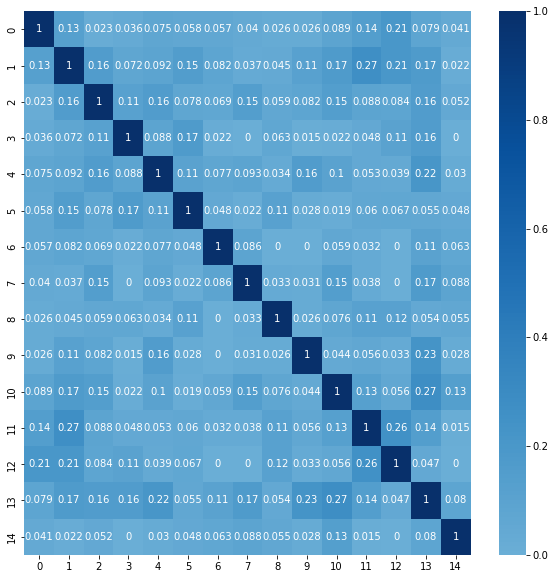

In [51]:
plt.figure(figsize=(10,10))
sns.heatmap(cos_sim_high, vmin = 0, vmax = 1, center = 0, cmap='Blues', annot = True)
plt.show()

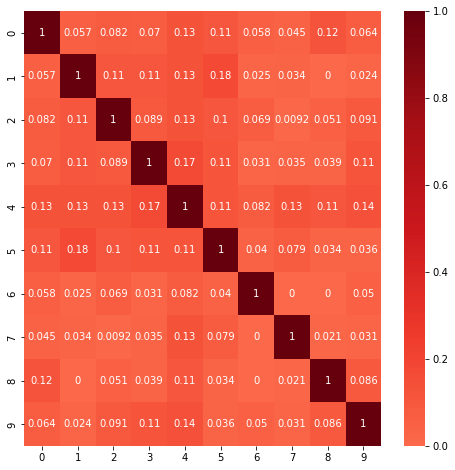

In [50]:
plt.figure(figsize=(8,8))
sns.heatmap(cos_sim_low, vmin = 0, vmax = 1, center = 0, cmap='Reds', annot = True)
plt.show()

No reviews are meaningfully similar to one another even if they give similar overall ratings

TFIDF

In [52]:
tfidf_vec_high = tfidf.fit_transform(reviews_high)

In [53]:
tfidf_terms_high = tfidf.get_feature_names()

In [54]:
high_tfidf_df = pd.DataFrame(tfidf_vec_high.toarray(), columns=tfidf_terms_high)
high_tfidf_df

,ach,achi,achil,actual,air,allergi,ankl,appear,april,arm,...,woke,work,wors,worst,worth,wrap,wrong,xray,yo,younger
0,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.184539,...,0.000000,0.270136,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000
1,0.116906,0.052164,0.0000,0.000000,0.000000,0.067316,0.000000,0.000000,0.000000,0.039931,...,0.058453,0.000000,0.134632,0.067316,0.000000,0.000000,0.067316,0.000000,0.000000,0.0000
2,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.284906,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000
3,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000
4,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.128187,0.000000,0.087569,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000
5,0.000000,0.114717,0.0000,0.148039,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.148039,0.000000,0.000000,0.000000,0.000000,0.0000
6,0.154955,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000
7,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.332961,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.429677,0.0000
8,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000
9,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.126120,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.145244,0.000000,0.0000


In [55]:
tfidf_vec_low = tfidf.fit_transform(reviews_low)

In [56]:
tfidf_terms_low = tfidf.get_feature_names()

In [57]:
low_tfidf_df = pd.DataFrame(tfidf_vec_low.toarray(), columns=tfidf_terms_low)
low_tfidf_df

,abl,ach,acid,activ,acut,ad,advil,ago,ankl,anti,...,way,wear,week,went,woke,work,wors,wrist,x,year
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.180974,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.199127,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.141141,0.000000,0.000000,0.282282,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.142682,0.000000,0.106117
4,0.000000,0.000000,0.051876,0.103752,0.000000,0.000000,0.051876,0.044099,0.000000,0.103752,...,0.051876,0.051876,0.132298,0.088199,0.051876,0.207504,0.000000,0.000000,0.051876,0.115745
5,0.000000,0.184136,0.000000,0.000000,0.184136,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.156532,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.281453,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.246238
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.138762,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.238093,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [58]:
high_tfidf_df.to_excel('high_tdidf_df.xlsx')
low_tfidf_df.to_excel('low_tfidf_df.xlsx')

Couldn't find any meaningful word used by tfidf between reviews.

Went trough TFIDF of each reviews, since we already found out that each reviews have little similarity.

In [59]:
from nltk.tokenize import sent_tokenize

In [60]:
review_high_tfidf_list = []
for each in reviews_high:
    sent_review = sent_tokenize(each)
    sent_review_tfidf = tfidf.fit_transform(sent_review)
    sent_review_terms = tfidf.get_feature_names()
    sent_review_tfidf_df = pd.DataFrame(sent_review_tfidf.toarray(), columns = sent_review_terms)
    review_high_tfidf_list.append(sent_review_tfidf_df)
review_high_tfidf_list[0]

,arm,booster,chanc,cold,come,day,did,dose,dress,feel,...,report,second,sore,start,stay,sweat,thank,till,vaccin,work
0,0.000000,0.0,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.226208,...,0.000000,0.000000,0.000000,0.308031,0.000000,0.000000,0.0,0.0,0.308031,0.000000
1,0.000000,0.0,0.000000,0.46936,0.46936,0.000000,0.46936,0.000000,0.000000,0.344683,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
2,0.000000,0.0,0.408248,0.00000,0.00000,0.000000,0.00000,0.000000,0.408248,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.408248,0.0,0.0,0.000000,0.000000
3,0.309927,0.0,0.000000,0.00000,0.00000,0.366945,0.00000,0.366945,0.000000,0.000000,...,0.000000,0.366945,0.366945,0.000000,0.366945,0.000000,0.0,0.0,0.000000,0.309927
4,0.362568,0.0,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.362568
5,0.000000,0.0,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
6,0.000000,0.5,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.5,0.000000,0.000000
7,0.000000,0.0,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.390352,...,0.531547,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
8,0.000000,0.0,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0,0.000000,0.000000


In [61]:
review_high_tfidf_list[0].to_excel('review_high_tfidf.xlsx')

In [62]:
i = 2
for df in review_high_tfidf_list[1:]:
    with pd.ExcelWriter('review_high_tfidf.xlsx', mode='a', engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name="tdidf" + str(i))
    i = i + 1

In [63]:
review_low_tfidf_list = []
for each in reviews_low:
    sent_review = sent_tokenize(each)
    sent_review_tfidf = tfidf.fit_transform(sent_review)
    sent_review_terms = tfidf.get_feature_names()
    sent_review_tfidf_df = pd.DataFrame(sent_review_tfidf.toarray(), columns = sent_review_terms)
    review_low_tfidf_list.append(sent_review_tfidf_df)
    
review_low_tfidf_list[0]

,burn,ckd,cortison,day,doctor,feet,foot,function,got,have,inject,kidney,left,lot,reliev,sensat,swell,swollen,vaccin,went
0,0.353553,0.176777,0.176777,0.353553,0.176777,0.353553,0.176777,0.176777,0.176777,0.176777,0.176777,0.176777,0.176777,0.176777,0.176777,0.353553,0.176777,0.176777,0.176777,0.176777


In [64]:
review_low_tfidf_list[0].to_excel('review_low_tfidf.xlsx')

In [65]:
i = 2
for df in review_low_tfidf_list[1:]:
    with pd.ExcelWriter('review_low_tfidf.xlsx', mode='a', engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name="tdidf" + str(i))
    i = i + 1